Questo è il Notebook relativo alla task 4 del progetto.

In [15]:
# Librerie
import numpy as np
from scipy.sparse import csc_matrix, coo_matrix
from scipy.sparse.linalg import spsolve_triangular
from sksparse.cholmod import cholesky
import time

# Funzione che legge le matrici in formato COO e restituisce la matrice in formato CSC
def read_coo_to_csc(a_filename):
    data_A = np.loadtxt(a_filename)
    rows = data_A[:, 0].astype(int)
    cols = data_A[:, 1].astype(int)
    vals = data_A[:, 2]
    A_coo = coo_matrix((vals, (rows, cols)))
    return A_coo.tocsc()

# Funzione che legge il termine noto b
def read_rhs(rhs_filename):
    return np.loadtxt(rhs_filename)

# Funzione che calcola la fattorizzazione di Cholesky di una matrice
def my_cholesky(A):
    try:
        factor = cholesky(A, order="natural")
    except TypeError:
        factor = cholesky(A, ordering_method="natural")
    # 'factor' e' una TUPLA: factor[0] e' il fattore superiore R (A = R^T R)
    R = csc_matrix(factor[0])
    return R.T.tocsc()  # restituisce la matrice triangolare inferiore L in formato CSC

# Funzione che risolve il sistema lineare Au = b usando la fattorizzazione di Cholesky
def solve_cholesky(L, b):
    y = spsolve_triangular(L, b, lower=True)            # Risolvo L y = b
    u = spsolve_triangular(L.T.tocsc(), y, lower=False)  # Risolvo L^T u = y
    return u


# --- Lettura dei dati ---
A_orig_CSC = read_coo_to_csc("A_orig.txt")
A_reordered_CSC = read_coo_to_csc("A_reordered.txt")

print("=== MATRICE ORIGINALE ===")
print(f"Dimensione : {A_orig_CSC.shape}")  # dimensione della matrice n x m
print(f"NNZ        : {A_orig_CSC.nnz}\n")  # numero di elementi non nulli

print("=== MATRICE RIORDINATA ===")
print(f"Dimensione : {A_reordered_CSC.shape}")
print(f"NNZ        : {A_reordered_CSC.nnz}\n")

# Cambio segno ad A e b: (-A) u = (-b) ha la stessa soluzione, con matrice definita positiva
A_orig = -A_orig_CSC
A_reordered = -A_reordered_CSC
b_orig = -read_rhs("rhs_orig.txt")
b_reordered = -read_rhs("rhs_reordered.txt")


# --- SISTEMA ORIGINALE: fattorizzazione e soluzione  ---
t0 = time.perf_counter()
L_orig = my_cholesky(A_orig)
t_fact_orig = time.perf_counter() - t0

t0 = time.perf_counter()
u_orig = solve_cholesky(L_orig, b_orig)
t_solve_orig = time.perf_counter() - t0

# --- SISTEMA RIORDINATO: fattorizzazione e soluzione ---
t0 = time.perf_counter()
L_reordered = my_cholesky(A_reordered)
t_fact_reord = time.perf_counter() - t0

t0 = time.perf_counter()
u_reordered = solve_cholesky(L_reordered, b_reordered)
t_solve_reord = time.perf_counter() - t0


# --- Stampa dei risultati ---
print("=== SISTEMA ORIGINALE ===")
print(f"Fill-in NNZ(L)   : {L_orig.nnz}\n")

print("=== SISTEMA RIORDINATO ===")
print(f"Fill-in NNZ(L)   : {L_reordered.nnz}\n")

# ATTENZIONE: u_orig e u_reordered contengono gli stessi valori in ordine diverso (N^2 elementi in totale)
print("Primi 10 elementi della soluzione:", u_orig[:10])
print("Primi 10 elementi della soluzione riordinata:", u_reordered[:10])

print("\n=== PRESTAZIONI (TEMPI IN SECONDI) ===")
print(f"Originale  -> Fattorizzazione: {t_fact_orig:.6f} s | Soluzione: {t_solve_orig:.6f} s | Totale: {t_fact_orig + t_solve_orig:.6f} s")
print(f"Riordinato -> Fattorizzazione: {t_fact_reord:.6f} s | Soluzione: {t_solve_reord:.6f} s | Totale: {t_fact_reord + t_solve_reord:.6f} s")
print(f"Speedup Fattorizzazione: {t_fact_orig / t_fact_reord:.2f}x")


=== MATRICE ORIGINALE ===
Dimensione : (262144, 262144)
NNZ        : 1308672

=== MATRICE RIORDINATA ===
Dimensione : (262144, 262144)
NNZ        : 1308672

=== SISTEMA ORIGINALE ===
Fill-in NNZ(L)   : 134218239

=== SISTEMA RIORDINATO ===
Fill-in NNZ(L)   : 11206792

Primi 10 elementi della soluzione: [0.00110965 0.00202933 0.00283416 0.00355945 0.00422456 0.00484141
 0.00541801 0.00596012 0.00647206 0.00695718]
Primi 10 elementi della soluzione riordinata: [0.00110965 0.00202933 0.00202933 0.00379365 0.00355945 0.00679941
 0.00283416 0.00536805 0.00355945 0.00679941]

=== PRESTAZIONI (TEMPI IN SECONDI) ===
Originale  -> Fattorizzazione: 23.935638 s | Soluzione: 12.721302 s | Totale: 36.656939 s
Riordinato -> Fattorizzazione: 0.985652 s | Soluzione: 0.843561 s | Totale: 1.829213 s
Speedup Fattorizzazione: 24.28x


Arrivati a questo punto non ci resta che da produrre i grafici delle soluzioni

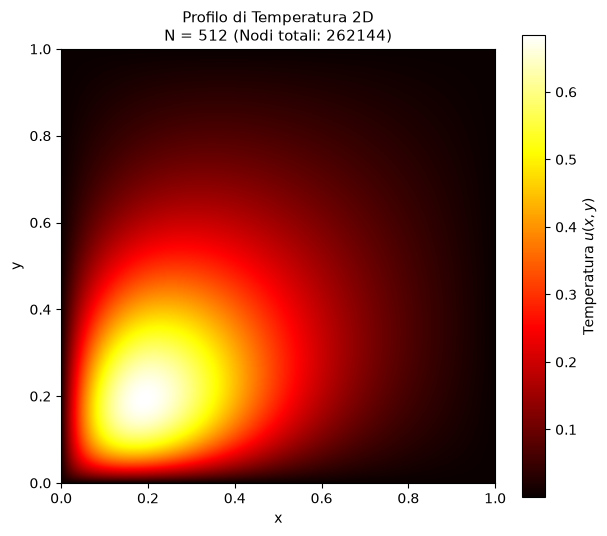

In [16]:
import matplotlib.pyplot as plt
import numpy as np


def plot_solution_2d(u, N=None, title="Profilo di Temperatura 2D"):
    # Se N non viene fornito esplicitamente, lo calcoliamo dalla lunghezza del vettore u
    if N is None:
        N = int(np.sqrt(len(u)))

    nodi_totali = N * N

    # Reshape del vettore 1D nella griglia 2D NxN
    U_grid = u.reshape((N, N), order="F") # in questo modo, la griglia viene riempita colonna per colonna, che è coerente con l'ordine di memorizzazione dei dati .

    plt.figure(figsize=(7, 6))

    # Mappa di calore 2D (imshow)
    im = plt.imshow(U_grid, cmap="hot", origin="lower", extent=[0, 1, 0, 1])

    plt.colorbar(im, label="Temperatura $u(x,y)$")

    # Titolo con Profilo di Temperatura 2D, N e Nodi Totali
    plt.title(
        f"{title}\nN = {N} (Nodi totali: {nodi_totali})",
        fontsize=11,
    )

    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(False)
    plt.show()

#plot per il sistema orginale
plot_solution_2d(u_orig, title="Profilo di Temperatura 2D")

